In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import boto3
import pickle
from pprint import pprint
import sklearn.metrics as skm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
# Suppress PerformanceWarning
warnings.filterwarnings('ignore')
try:
    import catboost as cb
except:
    ! pip install catboost
    import catboost as cb

### Functions

In [2]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

In [3]:
# get score
def get_score(y_class_true, y_hat_proba, str_eval_metric):
    if str_eval_metric == 'Logloss':
        flt_score = skm.log_loss(y_true=y_class_true, y_pred=y_hat_proba)
    elif str_eval_metric == 'AUC':
        flt_score = skm.roc_auc_score(y_true=y_class_true, y_score=y_hat_proba)
    else:
        pass
    # return
    return flt_score

In [4]:
def plot_distribution_of_predictions(df):
    list_tmp = list(df['yhat'])
    int_n = len(list_tmp)
    flt_mn = np.mean(list_tmp)
    flt_sd = np.std(list_tmp)
    flt_mdn = np.median(list_tmp)
    str_title = f"""
    Distribution of Predicted Probabilities (N = {int_n})
    Mn = {flt_mn:0.4f} (+/- SD = {flt_sd:0.4f}); Mdn = {flt_mdn:0.4f}
    """
    # ax
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(str_title)
    ax.set_xlabel('Predicted Probability')
    # plot
    sns.kdeplot(list_tmp, ax=ax)
    # show
    plt.show()

In [5]:
def plot_median_prediction_by_target(df):
    # group
    df_tmp = df.groupby(by='target', as_index=False).agg({
        'yhat': 'median',
    })
    x = df_tmp['target'].astype(str)
    y = df_tmp['yhat']
    # plot
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title('Median Predicted Probability by Target Value')
    ax.set_xlabel('Target')
    ax.set_ylabel('Predicted Probability')
    bars = ax.bar(x, y)

    # add value labels
    for bar, value in zip(bars, y):
        ax.text(
            bar.get_x() + bar.get_width()/2, 
            bar.get_height(), # vertical alignment
            round(value, 4),  # 4 decimal places
            ha='center', va='bottom', rotation=0, # horizontal alignment
        )

    plt.show()

In [6]:
def plot_mean_target_by_prediction_quantile(df, int_n_quantiles):
    df['yhat_quantile'] = pd.qcut(
        df['yhat'],
        q=int_n_quantiles,
        labels=list(range(1, int_n_quantiles+1)),
    )
    df_tmp = df.groupby(by='yhat_quantile', as_index=False).agg({
        'yhat': 'mean',
        'target': 'mean',
    })
    df_tmp.sort_values(by='yhat_quantile', ascending=True, inplace=True)

    # plot
    x = df_tmp['yhat_quantile']
    y = df_tmp['yhat']
    z = df_tmp['target']
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean Prediced Probability and Target by Prediction Quantile (N = {int_n_quantiles})')
    ax.set_xlabel('Prediction Quantile')
    ax.set_ylabel('Mean')
    ax.plot(x, y, label='Predicted Probability')
    ax.plot(x, z, label='Mean of Target')

    # legend
    plt.legend()

    # show
    plt.show()

In [7]:
def plot_distribution_of_predictions_by_data_set(df):
    list_str_eval_metric = [
        'Logloss',
        'AUC',
    ]
    df_tmp = df.groupby(by='data_set', as_index=False).agg({
        'target': lambda x: list(x),
        'yhat': lambda x: list(x),
    })
    list_tmp = [
        'train',
        'valid',
        'test',
    ]
    df_tmp['data_set'] = pd.Categorical(df_tmp['data_set'], categories=list_tmp, ordered=True)
    df_tmp.sort_values(by='data_set', inplace=True)
    for str_eval_metric in tqdm(list_str_eval_metric):
        # early
        df_tmp[f'{str_eval_metric}_early'] = df_tmp.apply(
            lambda x: get_score(
                y_class_true=x['target'],
                y_hat_proba=x['yhat'],
                str_eval_metric=str_eval_metric,
            ),
            axis=1,
        )
    dict_tmp = dict(zip(df_tmp['data_set'], df_tmp['yhat']))
    # plot
    list_tmp = [
        'train',
        'valid',
        'test',
    ]
    # distributions
    fig, ax = plt.subplots(figsize=(9,5))
    # title
    ax.set_title('Distributions of Predictions')
    # x
    ax.set_xlabel('Predicted Probability')
    for str_df in tqdm(list_tmp):
        str_df_label = str_df.capitalize()
        list_tmp = dict_tmp[str_df]
        flt_mn = np.mean(list_tmp)
        flt_sd = np.std(list_tmp)
        flt_mdn = np.median(list_tmp)
        str_label = f'{str_df_label} - Mn: {flt_mn:0.2f} (+/- SD: {flt_sd:0.2f}); Mdn: {flt_mdn:0.2f}'
        sns.kdeplot(list_tmp, ax=ax, label=str_label)
    # legend
    plt.legend()
    # show
    plt.show()

In [8]:
def plot_distributions_by_bk_type(df):
    df_tmp = df.groupby(by='intopenbktype__app', as_index=False).agg({
        'yhat': lambda x: list(x),
    })
    dict_tmp = dict(zip(df_tmp['intopenbktype__app'], df_tmp['yhat']))
    list_tmp = [
        '7.0',
        '13.0',
        'nan',
    ]
    fig, ax = plt.subplots(figsize=(9,5))
    # title
    ax.set_title('Distributions of Predictions')
    # x
    ax.set_xlabel('Predicted Probability')
    for str_bk in tqdm(list_tmp):
        str_df_label = str_bk
        list_tmp = dict_tmp[str_bk]
        flt_mn = np.mean(list_tmp)
        flt_sd = np.std(list_tmp)
        flt_mdn = np.median(list_tmp)
        str_label = f'{str_df_label} - Mn: {flt_mn:0.2f} (+/- SD: {flt_sd:0.2f}); Mdn: {flt_mdn:0.2f}'
        sns.kdeplot(list_tmp, ax=ax, label=str_label)
    # legend
    plt.legend()
    # show
    plt.show()

In [9]:
def plot_distributions_by_dealership_type(df):
    df_tmp = df.groupby(by='strdealershiptrackertype__app', as_index=False).agg({
        'yhat': lambda x: list(x),
    })
    dict_tmp = dict(zip(df_tmp['strdealershiptrackertype__app'], df_tmp['yhat']))
    list_tmp = [
        'franchise',
        'independent',
        'referral',
    ]
    fig, ax = plt.subplots(figsize=(9,5))
    # title
    ax.set_title('Distributions of Predictions')
    # x
    ax.set_xlabel('Predicted Probability')
    for str_bk in tqdm(list_tmp):
        try:
            str_df_label = str_bk.capitalize()
            list_tmp = dict_tmp[str_bk]
            flt_mn = np.mean(list_tmp)
            flt_sd = np.std(list_tmp)
            flt_mdn = np.median(list_tmp)
            str_label = f'{str_df_label} - Mn: {flt_mn:0.2f} (+/- SD: {flt_sd:0.2f}); Mdn: {flt_mdn:0.2f}'
            sns.kdeplot(list_tmp, ax=ax, label=str_label)
        except:
            pass
    # legend
    plt.legend()
    # show
    plt.show()

In [10]:
def plot_mean_ltv_yhat_actual_by_ltv_quantile(df, int_n_quantiles):
    df['ltv_quantile'] = pd.qcut(
        df['ENG-loan_to_value'],
        q=int_n_quantiles,
        labels=list(range(1, int_n_quantiles+1)),
    )
    df_tmp = df.groupby(by='ltv_quantile', as_index=False).agg({
        'ENG-loan_to_value': 'mean',
        'yhat': 'mean',
        'target': 'mean',
    })
    df_tmp.sort_values(by='ltv_quantile', ascending=True, inplace=True)
    # plot
    x = df_tmp['ltv_quantile'].astype(str)
    y = df_tmp['ENG-loan_to_value']
    z = df_tmp['yhat']
    a = df_tmp['target']
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean LTV, Prediction, and Actual by LTV Quantile (N = {int_n_quantiles})')
    ax.set_xlabel('LTV Quantile')
    ax.set_ylabel('LTV')
    ax.plot(x, y, label='LTV')
    plt.legend()
    # second y
    ax2 = ax.twinx()
    ax2.set_ylabel('Mean Predicted and Actual')
    ax2.plot(x, z, label='Prediction', color='red')
    ax2.plot(x, a, label='Actual', color='green')
    # legend
    plt.legend()
    # show
    plt.show()

In [11]:
def plot_mean_income_yhat_actual_by_income_quantile(df, int_n_quantiles):
    df['income_quantile'] = pd.qcut(
        df['fltgrossmonthly__income_sum'],
        q=int_n_quantiles,
        labels=list(range(1, int_n_quantiles+1)),
    )
    df_tmp = df.groupby(by='income_quantile', as_index=False).agg({
        'fltgrossmonthly__income_sum': 'mean',
        'yhat': 'mean',
        'target': 'mean',
    })
    df_tmp.sort_values(by='income_quantile', ascending=True, inplace=True)
    # plot
    x = df_tmp['income_quantile'].astype(str)
    y = df_tmp['fltgrossmonthly__income_sum']
    z = df_tmp['yhat']
    a = df_tmp['target']
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Mean Income, Prediction, and Actual by Income Quantile (N = {int_n_quantiles})')
    ax.set_xlabel('Income Quantile')
    ax.set_ylabel('Income')
    ax.plot(x, y, label='Income')
    plt.legend()
    # second y
    ax2 = ax.twinx()
    ax2.set_ylabel('Mean Predicted and Actual')
    ax2.plot(x, z, label='Prediction', color='red')
    ax2.plot(x, a, label='Actual', color='green')
    # legend
    plt.legend()
    # show
    plt.show()

### Constants

In [12]:
str_dirname_output = './output'

str_variant = 'noPTImodel10'

# get the time
str_time = os.getcwd().split('/')[-1]
str_target = f'Early_Pay_Delinquency_{str_time}_Flag'
print(f'Target: {str_target}')

int_n_quantiles = 20

Target: Early_Pay_Delinquency_15_60_Flag


### Output directory

In [13]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Load data

In [14]:
str_filename = 'df.gzip'
str_uri = f's3://20231010-gen-xii/14_monitoring/05_get_data/{str_filename}'
df = pd.read_parquet(str_uri)
df

,bigAccountId,data_set,fltgrossmonthly__income_sum,intopenbktype__app,bankruptcystatus__ln,bankruptcycount24month__ln,strname__app,strdealershiptrackertype__app,g990s__tu,bankruptcytimenewest__ln,...,agg903__tu,ret205__tu,at25s__tu,rev315__tu,g206b__tu,st25s__tu,businessassociationtimeoldest__ln,g218d__tu,ENG-loan_to_value,fltapproveddowntotal__app
38325,1337511,train,5000.0,nan,0.0,0.0,ohio,franchise,7.0,-1.0,...,0.0,-1.00,1.0,-1.0,0.000000,-1.0,-1.0,-1.0,1.370370,2500.0
38324,1337511,train,5000.0,nan,0.0,0.0,ohio,franchise,7.0,-1.0,...,0.0,-1.00,1.0,-1.0,0.000000,-1.0,-1.0,-1.0,1.370370,2500.0
38326,1337528,train,2000.0,7.0,1.0,1.0,tennessee,independent,2.0,4.0,...,1.0,8.02,1.0,7.0,0.000000,-1.0,-1.0,-1.0,1.586207,0.0
38327,1337528,train,2000.0,7.0,1.0,1.0,tennessee,independent,2.0,4.0,...,1.0,8.02,1.0,7.0,0.000000,-1.0,-1.0,-1.0,1.586207,0.0
38329,1337539,train,11000.0,nan,0.0,0.0,texas,independent,0.0,-1.0,...,0.0,-1.00,2.0,13.0,561.549063,1.0,-1.0,2.0,1.342857,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7864,4812498,test,5500.0,nan,0.0,0.0,georgia,franchise,-4.0,-1.0,...,0.0,-2.00,3.0,-1.0,374.322569,0.0,-1.0,-1.0,1.548387,0.0
7863,4812498,test,5500.0,nan,0.0,0.0,georgia,franchise,-4.0,-1.0,...,0.0,-2.00,3.0,-1.0,374.322569,0.0,-1.0,-1.0,1.548387,0.0
20360,4812503,test,4500.0,7.0,1.0,0.0,alabama,franchise,5.0,75.0,...,2.0,-1.00,4.0,2.0,0.000000,1.0,-1.0,0.0,1.044444,3500.0
20361,4812503,test,4500.0,7.0,1.0,0.0,alabama,franchise,5.0,75.0,...,2.0,-1.00,4.0,2.0,0.000000,1.0,-1.0,0.0,1.044444,3500.0


### Get the target

In [15]:
# get the early indicator targets
list_cols = ['bigAccountId', str_target]
str_filename = 'df_targets.gzip'
str_uri = f's3://20240327-genxii-v2/02_target_creation/01_classification/{str_filename}'
df_tmp = pd.read_parquet(str_uri, columns=list_cols)
df_tmp

,bigAccountId,Early_Pay_Delinquency_15_60_Flag
0,6,0
1,25,1
2,73,0
3,82,1
4,122,0
...,...,...
331103,7897024,0
331104,7897157,0
331105,7897219,0
331106,7898715,0


### Join

In [16]:
df = pd.merge(
    left=df,
    right=df_tmp,
    on='bigAccountId',
    how='left',
)
# rename
dict_rename = {
    str_target: 'target',
}
df.rename(columns=dict_rename, inplace=True)
# show
df

,bigAccountId,data_set,fltgrossmonthly__income_sum,intopenbktype__app,bankruptcystatus__ln,bankruptcycount24month__ln,strname__app,strdealershiptrackertype__app,g990s__tu,bankruptcytimenewest__ln,...,ret205__tu,at25s__tu,rev315__tu,g206b__tu,st25s__tu,businessassociationtimeoldest__ln,g218d__tu,ENG-loan_to_value,fltapproveddowntotal__app,target
0,1337511,train,5000.0,nan,0.0,0.0,ohio,franchise,7.0,-1.0,...,-1.00,1.0,-1.0,0.000000,-1.0,-1.0,-1.0,1.370370,2500.0,0
1,1337511,train,5000.0,nan,0.0,0.0,ohio,franchise,7.0,-1.0,...,-1.00,1.0,-1.0,0.000000,-1.0,-1.0,-1.0,1.370370,2500.0,0
2,1337528,train,2000.0,7.0,1.0,1.0,tennessee,independent,2.0,4.0,...,8.02,1.0,7.0,0.000000,-1.0,-1.0,-1.0,1.586207,0.0,0
3,1337528,train,2000.0,7.0,1.0,1.0,tennessee,independent,2.0,4.0,...,8.02,1.0,7.0,0.000000,-1.0,-1.0,-1.0,1.586207,0.0,0
4,1337539,train,11000.0,nan,0.0,0.0,texas,independent,0.0,-1.0,...,-1.00,2.0,13.0,561.549063,1.0,-1.0,2.0,1.342857,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186170,4812498,test,5500.0,nan,0.0,0.0,georgia,franchise,-4.0,-1.0,...,-2.00,3.0,-1.0,374.322569,0.0,-1.0,-1.0,1.548387,0.0,0
186171,4812498,test,5500.0,nan,0.0,0.0,georgia,franchise,-4.0,-1.0,...,-2.00,3.0,-1.0,374.322569,0.0,-1.0,-1.0,1.548387,0.0,0
186172,4812503,test,4500.0,7.0,1.0,0.0,alabama,franchise,5.0,75.0,...,-1.00,4.0,2.0,0.000000,1.0,-1.0,0.0,1.044444,3500.0,0
186173,4812503,test,4500.0,7.0,1.0,0.0,alabama,franchise,5.0,75.0,...,-1.00,4.0,2.0,0.000000,1.0,-1.0,0.0,1.044444,3500.0,0


### Generate predictions from early indicator model

In [17]:
str_filename = 'cls_model_inference.pkl'
str_local_path = f'../../07_models/{str_time}/output/{str_filename}'
cls_model_inference = pickle.load(open(str_local_path, 'rb'))
# get features
list_cols_model = list(cls_model_inference.feature_names_)
print(f'There are {len(list_cols_model)} columns in the early indicator model')
# get predictions
df['yhat'] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]
# show
df

There are 122 columns in the early indicator model


,bigAccountId,data_set,fltgrossmonthly__income_sum,intopenbktype__app,bankruptcystatus__ln,bankruptcycount24month__ln,strname__app,strdealershiptrackertype__app,g990s__tu,bankruptcytimenewest__ln,...,at25s__tu,rev315__tu,g206b__tu,st25s__tu,businessassociationtimeoldest__ln,g218d__tu,ENG-loan_to_value,fltapproveddowntotal__app,target,yhat
0,1337511,train,5000.0,nan,0.0,0.0,ohio,franchise,7.0,-1.0,...,1.0,-1.0,0.000000,-1.0,-1.0,-1.0,1.370370,2500.0,0,0.199738
1,1337511,train,5000.0,nan,0.0,0.0,ohio,franchise,7.0,-1.0,...,1.0,-1.0,0.000000,-1.0,-1.0,-1.0,1.370370,2500.0,0,0.207227
2,1337528,train,2000.0,7.0,1.0,1.0,tennessee,independent,2.0,4.0,...,1.0,7.0,0.000000,-1.0,-1.0,-1.0,1.586207,0.0,0,0.107255
3,1337528,train,2000.0,7.0,1.0,1.0,tennessee,independent,2.0,4.0,...,1.0,7.0,0.000000,-1.0,-1.0,-1.0,1.586207,0.0,0,0.103310
4,1337539,train,11000.0,nan,0.0,0.0,texas,independent,0.0,-1.0,...,2.0,13.0,561.549063,1.0,-1.0,2.0,1.342857,0.0,0,0.158795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186170,4812498,test,5500.0,nan,0.0,0.0,georgia,franchise,-4.0,-1.0,...,3.0,-1.0,374.322569,0.0,-1.0,-1.0,1.548387,0.0,0,0.075879
186171,4812498,test,5500.0,nan,0.0,0.0,georgia,franchise,-4.0,-1.0,...,3.0,-1.0,374.322569,0.0,-1.0,-1.0,1.548387,0.0,0,0.077229
186172,4812503,test,4500.0,7.0,1.0,0.0,alabama,franchise,5.0,75.0,...,4.0,2.0,0.000000,1.0,-1.0,0.0,1.044444,3500.0,0,0.059015
186173,4812503,test,4500.0,7.0,1.0,0.0,alabama,franchise,5.0,75.0,...,4.0,2.0,0.000000,1.0,-1.0,0.0,1.044444,3500.0,0,0.058480


### Distribution of predictions

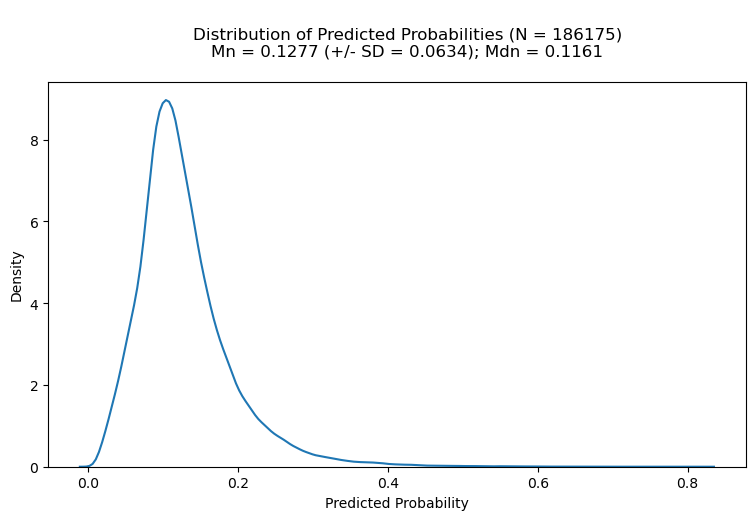

In [18]:
plot_distribution_of_predictions(df=df)

### Median prediction by target

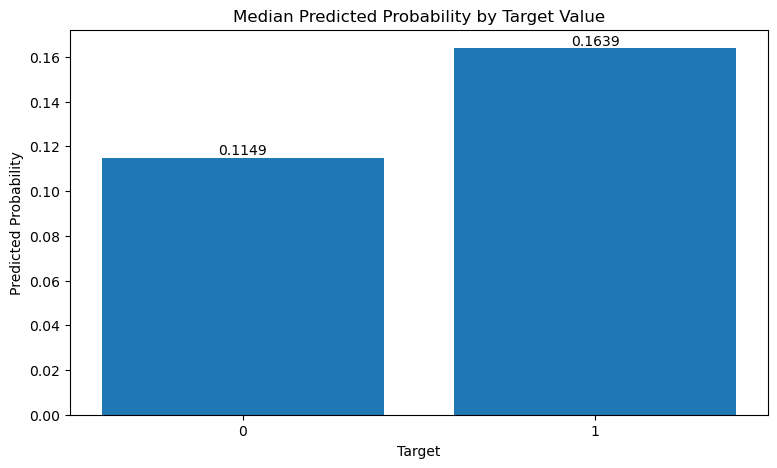

In [19]:
plot_median_prediction_by_target(df=df)

### Mean target by prediction quantile

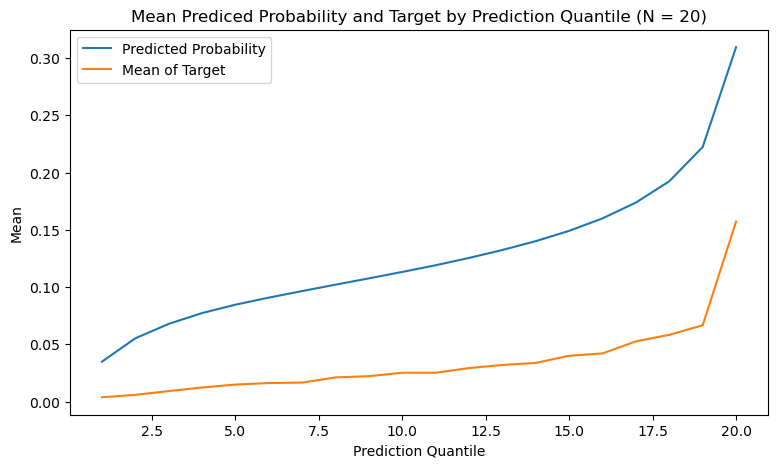

In [20]:
plot_mean_target_by_prediction_quantile(
    df=df,
    int_n_quantiles=int_n_quantiles,
)

### Distribution of predictions by data set

100%|██████████| 3/3 [00:00<00:00,  3.29it/s]


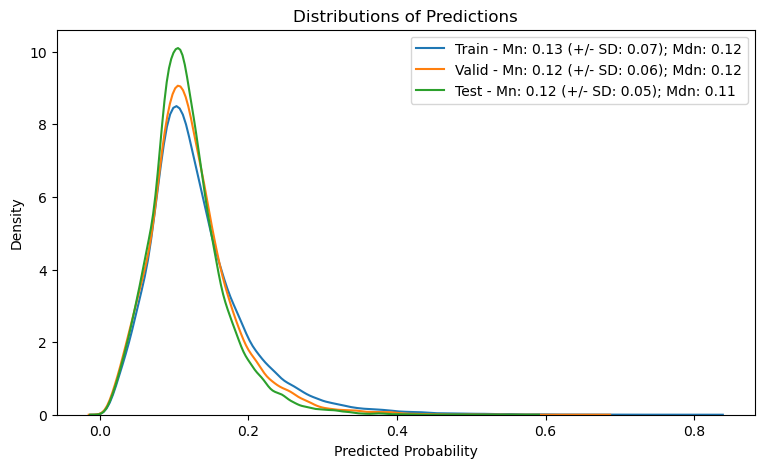

In [21]:
plot_distribution_of_predictions_by_data_set(df=df)

### Mean target by prediction quantile by data set

  0%|          | 0/3 [00:00<?, ?it/s]

Train


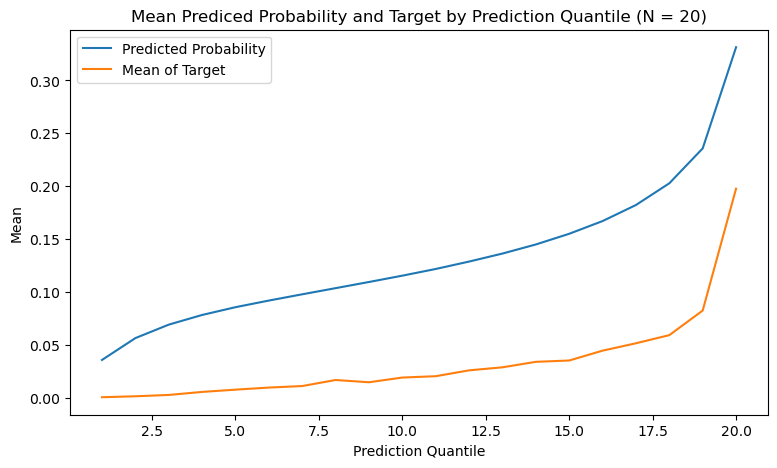

 33%|███▎      | 1/3 [00:00<00:00,  2.73it/s]


Valid


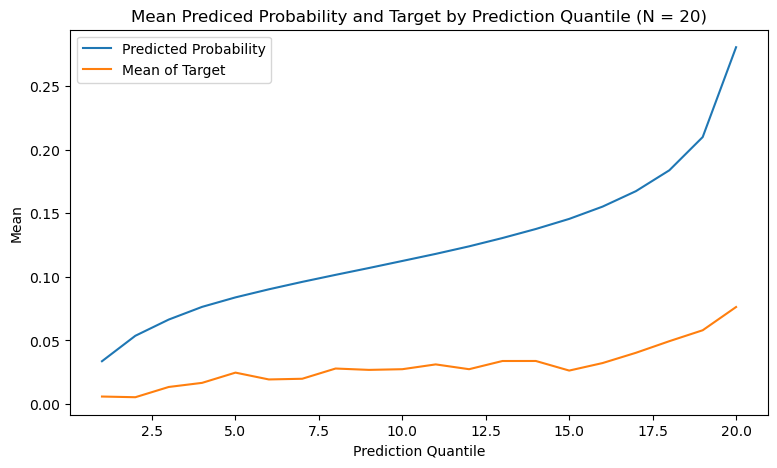

 67%|██████▋   | 2/3 [00:00<00:00,  3.34it/s]


Test


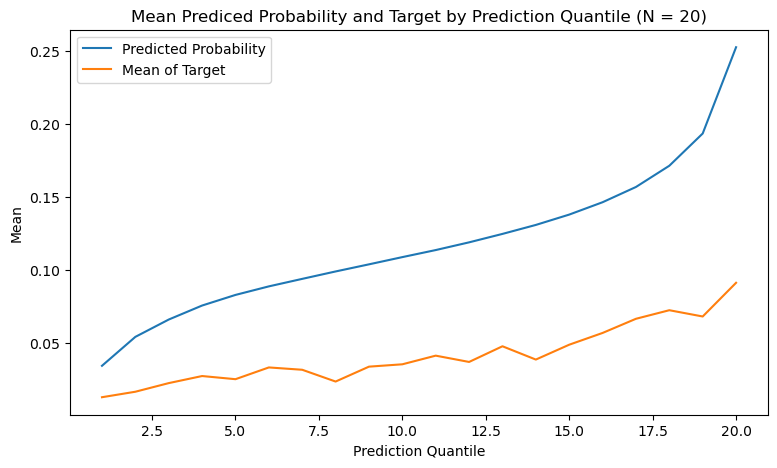

100%|██████████| 3/3 [00:00<00:00,  3.47it/s]

In [22]:
list_str_df = [
    'train',
    'valid',
    'test',
]
for str_df in tqdm(list_str_df):
    print(f'{str_df.capitalize()}')
    plot_mean_target_by_prediction_quantile(
        df=df[df['data_set'] == str_df].copy(),
        int_n_quantiles=int_n_quantiles,
    )
    print()

### Test data only

In [23]:
df = df[df['data_set'] == 'test'].copy()
# show
df

,bigAccountId,data_set,fltgrossmonthly__income_sum,intopenbktype__app,bankruptcystatus__ln,bankruptcycount24month__ln,strname__app,strdealershiptrackertype__app,g990s__tu,bankruptcytimenewest__ln,...,rev315__tu,g206b__tu,st25s__tu,businessassociationtimeoldest__ln,g218d__tu,ENG-loan_to_value,fltapproveddowntotal__app,target,yhat,yhat_quantile
148940,3932700,test,5500.0,nan,0.0,0.0,ohio,franchise,-4.0,-1.0,...,-1.0,0.000000,-1.0,-1.0,-1.0,1.282051,500.0,0,0.103717,8
148941,3932720,test,8000.0,nan,0.0,0.0,tennessee,franchise,4.0,-1.0,...,1.0,544.269515,-3.0,-1.0,-1.0,1.322581,2500.0,0,0.112568,10
148942,3932720,test,8000.0,nan,0.0,0.0,tennessee,franchise,4.0,-1.0,...,1.0,544.269515,-3.0,-1.0,-1.0,1.322581,2500.0,0,0.117915,11
148943,3932724,test,3000.0,nan,0.0,0.0,ohio,franchise,2.0,-1.0,...,2.0,0.000000,-3.0,-1.0,0.0,1.195652,0.0,0,0.124291,12
148944,3932724,test,3000.0,nan,0.0,0.0,ohio,franchise,2.0,-1.0,...,2.0,0.000000,-3.0,-1.0,0.0,1.195652,0.0,0,0.121342,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186170,4812498,test,5500.0,nan,0.0,0.0,georgia,franchise,-4.0,-1.0,...,-1.0,374.322569,0.0,-1.0,-1.0,1.548387,0.0,0,0.075879,4
186171,4812498,test,5500.0,nan,0.0,0.0,georgia,franchise,-4.0,-1.0,...,-1.0,374.322569,0.0,-1.0,-1.0,1.548387,0.0,0,0.077229,4
186172,4812503,test,4500.0,7.0,1.0,0.0,alabama,franchise,5.0,75.0,...,2.0,0.000000,1.0,-1.0,0.0,1.044444,3500.0,0,0.059015,2
186173,4812503,test,4500.0,7.0,1.0,0.0,alabama,franchise,5.0,75.0,...,2.0,0.000000,1.0,-1.0,0.0,1.044444,3500.0,0,0.058480,2


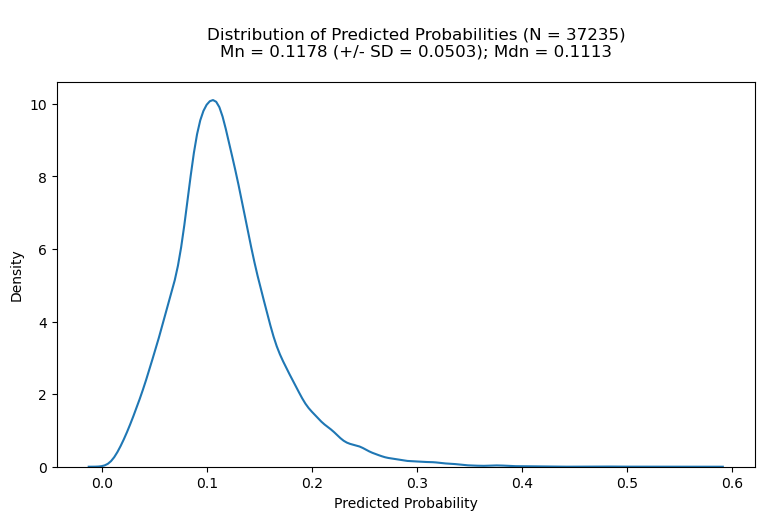

In [24]:
# distribution of predictions
plot_distribution_of_predictions(df=df)

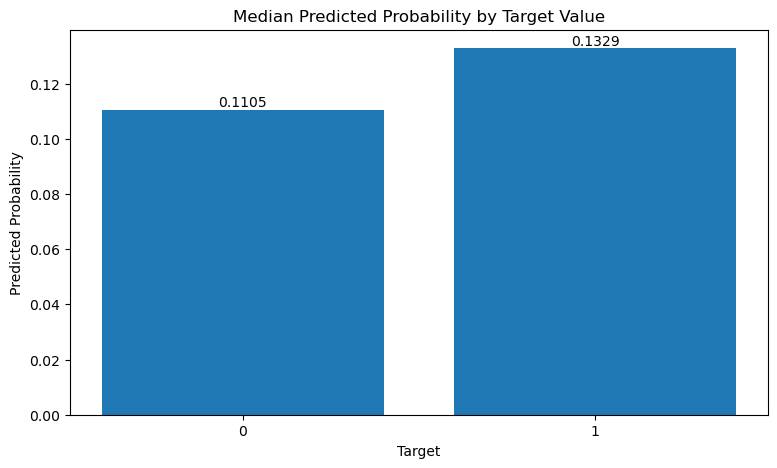

In [25]:
# median prediction by target
plot_median_prediction_by_target(df=df)

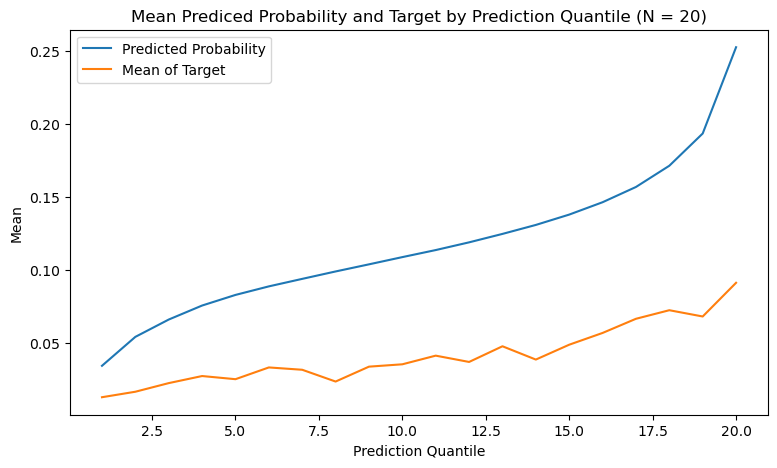

In [26]:
# mean target by prediction quantile
plot_mean_target_by_prediction_quantile(
    df=df,
    int_n_quantiles=int_n_quantiles,
)

100%|██████████| 3/3 [00:00<00:00, 13.19it/s]


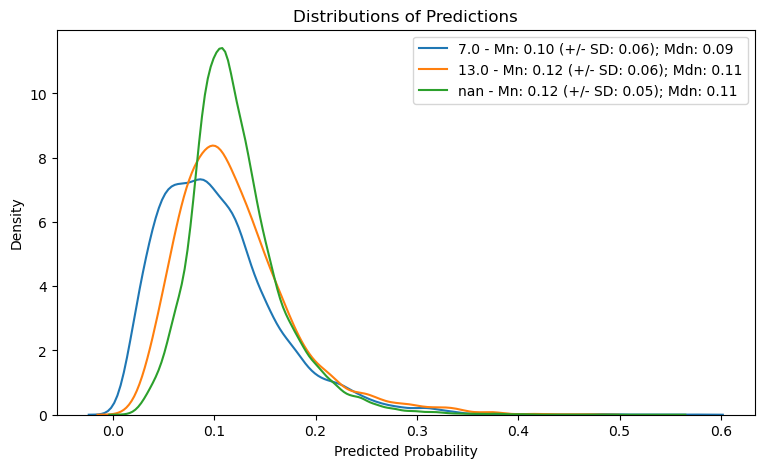

In [27]:
# distributions by bk type
plot_distributions_by_bk_type(df=df)

100%|██████████| 3/3 [00:00<00:00, 13.84it/s]


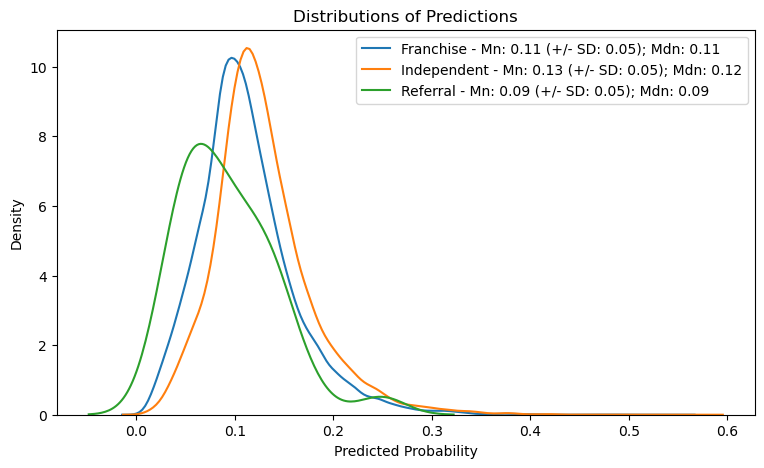

In [28]:
# distribution by dealership tracker type
plot_distributions_by_dealership_type(df=df)

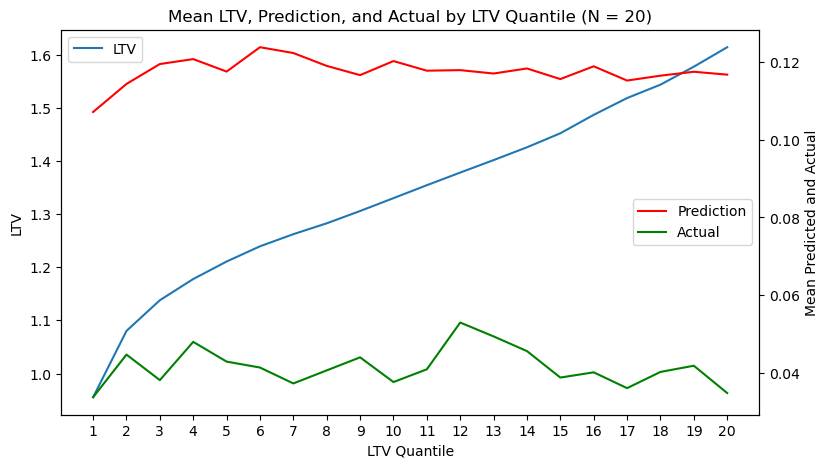

In [29]:
# mean ltv, yhat, and actual by ltv quantile
plot_mean_ltv_yhat_actual_by_ltv_quantile(
    df=df,
    int_n_quantiles=int_n_quantiles,
)

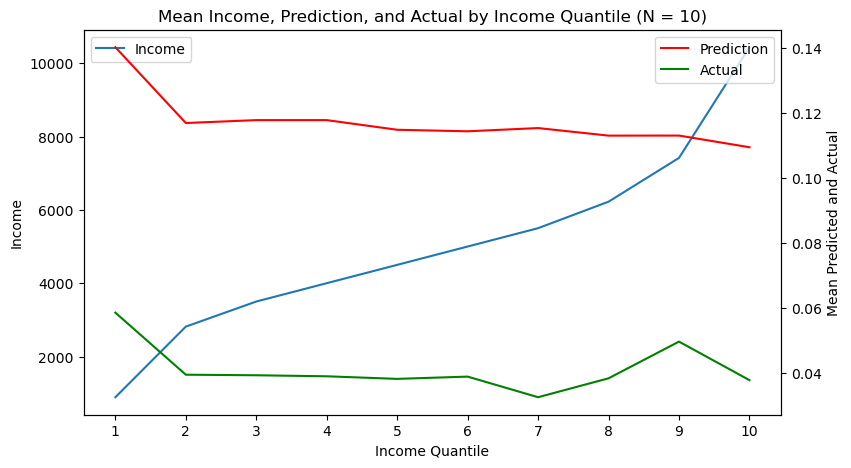

In [30]:
# income, predictions, and actuals by income quantile
plot_mean_income_yhat_actual_by_income_quantile(
    df=df,
    int_n_quantiles=10,
)

### Holdout data

In [31]:
str_filename = 'df_holdout_raw.gzip'
str_uri = f's3://20240327-genxii-v2/04_pd/01_data_prep/03_train_valid_test_split/{str_filename}'
df = pd.read_parquet(str_uri)
list_id = list(df['bigaccountid__app'])
df

,uniqueid__app_x,bigstatusid__app,strcity__app,strname__app,strzipcode__app,bitapproved__app,bitsystemdecline__app,approvaldate__app,bitfunded__app,fundeddate__app,...,bitservicecontract__app,fltadvance__app,strvehicletype__app,bitgap__app,dealerstampcreation__app,funded_month,bigDebtorId,fico__app,target,application_month
17095,0__0__20220301,5951341.0,PANAMA CITY,Florida,32404,False,0.0,NaN,False,NaN,...,0,1.149329,auto,0,2020-02-11 16:01:55.267,2022-03,7463994,562.0,0,2022-03
17098,0__0__20220301,5951341.0,PANAMA CITY,Florida,32404,False,0.0,NaN,False,NaN,...,0,1.149329,auto,0,2020-02-11 16:01:55.267,2022-03,7463995,562.0,0,2022-03
15193,0__0__20220301,5951349.0,DETROIT,Michigan,48227,False,0.0,NaN,False,NaN,...,0,0.964219,suv,0,2021-12-22 16:24:25.010,2022-03,7464004,471.0,1,2022-03
17119,0__0__20220301,5951363.0,NEWPORT NEWS,Virginia,23605,False,0.0,NaN,False,NaN,...,0,1.166993,auto,0,2013-05-08 08:47:59.997,2022-03,7464020,498.0,0,2022-03
14848,0__0__20220301,5951374.0,Greenwood,Indiana,46143,False,0.0,NaN,False,NaN,...,0,1.023030,suv,0,2013-07-18 09:37:34.627,2022-03,7464032,501.0,0,2022-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23151,0__0__20220524,11.0,Phoenix,Arizona,85037,False,0.0,NaN,False,NaN,...,0,1.183095,suv,1,2021-03-12 12:19:39.870,2022-05,7621643,671.0,0,2022-05
23429,0__0__20220524,11.0,Peoria,Arizona,85345,False,0.0,NaN,False,NaN,...,1,1.159616,suv,1,2003-07-08 14:32:29.097,2022-05,7621726,536.0,1,2022-05
23415,0__0__20220526,11.0,BELLWOOD,Illinois,60104,False,0.0,NaN,False,NaN,...,0,1.110925,auto,0,2008-08-21 16:54:01.283,2022-05,7624189,558.0,0,2022-05
23515,0__0__20220526,11.0,AKRON,Ohio,44307,False,0.0,NaN,False,NaN,...,0,1.055477,auto,1,2012-01-20 14:20:33.923,2022-05,7624946,559.0,0,2022-05


In [32]:
# get non-leaky features
str_filename = 'df_test_noleaks.gzip'
str_uri = f's3://20240327-genxii-v2/04_pd/01_data_prep/05_leaky_features/04_write_dfs/{str_filename}'
list_cols = list(pd.read_parquet(str_uri).columns)
print(f'There are {len(list_cols)} non-leaky features')
# get those that are in df
list_cols = [col for col in list_cols if col in list(df.columns)]
# ensure some in there
list_cols = list_cols + ['linka060__tu']
print(f'There are {len(list_cols)} non-leaky features in df')

There are 1496 non-leaky features
There are 1495 non-leaky features in df


In [33]:
# subset
df = df[list_cols].copy()
df

,linkf106__tu,intopenbktype__app,linkf060__tu,linkf045__tu,linkf189__tu,linkf185__tu,linkf193__tu,linkf195__tu,linkf105__tu,linkf118__tu,...,vehicleyear__app,strname__app,dealerstate__app,bitdealerapplicantsamezip__app,strdealershiptrackertype__app,bitdealertrack__app,uniqueid,applicationdate__app,target,linka060__tu
17095,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2019,Florida,Florida,0,Franchise,True,NaN,2022-03-01 07:47:45.010,0,0.0
17098,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2019,Florida,Florida,0,Franchise,True,NaN,2022-03-01 07:47:45.010,0,0.0
15193,2070.0,NaN,NaN,NaN,1324.0,123.0,123.0,2070.0,123.0,0.0,...,2020,Michigan,Michigan,0,Independent,True,NaN,2022-03-01 07:59:06.407,1,0.0
17119,1890.0,7.0,NaN,NaN,189.0,525.0,189.0,1890.0,189.0,0.0,...,2017,Virginia,Ohio,0,Franchise,False,NaN,2022-03-01 08:15:52.030,0,0.0
14848,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2017,Indiana,Indiana,0,Franchise,False,NaN,2022-03-01 08:23:02.303,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23151,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2017,Arizona,Arizona,0,Independent,False,NaN,2022-05-24 16:40:33.143,0,NaN
23429,NaN,7.0,0.0,0.0,19.0,31.0,19.0,1755.0,19.0,0.0,...,2014,Arizona,Arizona,0,Franchise,False,NaN,2022-05-24 17:11:06.627,1,0.0
23415,NaN,NaN,0.0,0.0,512.0,1295.0,512.0,1295.0,512.0,0.0,...,2017,Illinois,Illinois,0,Franchise,True,NaN,2022-05-26 09:48:15.047,0,0.0
23515,2025.0,7.0,NaN,484.0,136.0,195.0,136.0,2025.0,136.0,0.0,...,2015,Ohio,Ohio,0,Franchise,True,NaN,2022-05-26 14:07:25.600,0,0.0


In [34]:
# preprocess
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    # download
    str_bucket_path = f'01_ad/02_model/{str_variant}/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        str_local_path=str_local_path, 
        str_bucket_path=str_bucket_path, 
        str_project='20231010-gen-xii',
    )
# import
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))

# preprocess
df = cls_model_preprocessing.transform(df)
# rm
list_str_filename = [
    'cls_model_preprocessing.pkl',
    'preprocessing.py',
]
for str_filename in tqdm(list_str_filename):
    str_local_path = f'./{str_filename}'
    os.remove(str_local_path)
# show
df

100%|██████████| 2/2 [00:00<00:00,  8.33it/s]


NaN Replacer: 0.034956 sec.


100%|██████████| 3/3 [00:00<00:00, 572.24it/s]


Unable to convert vehiclemodel__app to string, not found in data
Set strings: 0.0073846 sec.
Boolean Replacer: 0.10903 sec.


100%|██████████| 1487/1487 [00:00<00:00, 3761.25it/s]


...

Replace inf and -inf with NaN: 0.76468 sec.
Imputer: 0.10287 sec.
Map term: 7.5478e-05 sec.
Map PTI: 3.5372e-05 sec.


100%|██████████| 6/6 [00:00<00:00, 1401.92it/s]


Round values: 0.0075214 sec.
Preprocessing Model: 2.4013 sec.


100%|██████████| 2/2 [00:00<00:00, 4851.71it/s]


,linkf106__tu,intopenbktype__app,linkf060__tu,linkf045__tu,linkf189__tu,linkf185__tu,linkf193__tu,linkf195__tu,linkf105__tu,linkf118__tu,...,applicationdate__app,target,linka060__tu,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age
17095,0.0,nan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2022-03-01 07:47:45.010,0,0.0,2022,1.0,3,1,1.272727,3.0,2.049315
17098,0.0,nan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2022-03-01 07:47:45.010,0,0.0,2022,1.0,3,1,1.272727,3.0,2.049315
15193,2070.0,nan,0.0,0.0,1324.0,123.0,123.0,2070.0,123.0,0.0,...,2022-03-01 07:59:06.407,1,0.0,2022,1.0,3,1,1.061224,2.0,0.186301
17119,1890.0,7.0,0.0,0.0,189.0,525.0,189.0,1890.0,189.0,0.0,...,2022-03-01 08:15:52.030,0,0.0,2022,1.0,3,1,1.222222,5.0,8.816438
14848,0.0,nan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2022-03-01 08:23:02.303,0,0.0,2022,1.0,3,1,1.048780,5.0,8.621918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23151,0.0,nan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2022-05-24 16:40:33.143,0,0.0,2022,1.0,5,2,1.367347,5.0,1.200000
23429,0.0,7.0,0.0,0.0,19.0,31.0,19.0,1755.0,19.0,0.0,...,2022-05-24 17:11:06.627,1,0.0,2022,1.0,5,2,1.531250,8.0,18.890411
23415,0.0,nan,0.0,0.0,512.0,1295.0,512.0,1295.0,512.0,0.0,...,2022-05-26 09:48:15.047,0,0.0,2022,1.0,5,2,1.243902,5.0,13.767123
23515,2025.0,7.0,0.0,484.0,136.0,195.0,136.0,2025.0,136.0,0.0,...,2022-05-26 14:07:25.600,0,0.0,2022,1.0,5,2,1.193548,7.0,10.350685


In [35]:
# subset to cols in model
df = df[list_cols_model].copy()

In [36]:
# assign id
df['bigAccountId'] = list_id

In [37]:
# get the early indicator targets
list_cols = ['bigAccountId', str_target]
str_filename = 'df_targets.gzip'
str_uri = f's3://20240327-genxii-v2/02_target_creation/01_classification/{str_filename}'
df_tmp = pd.read_parquet(str_uri, columns=list_cols)
df_tmp

,bigAccountId,Early_Pay_Delinquency_15_60_Flag
0,6,0
1,25,1
2,73,0
3,82,1
4,122,0
...,...,...
331103,7897024,0
331104,7897157,0
331105,7897219,0
331106,7898715,0


In [38]:
# join
df = pd.merge(
    left=df,
    right=df_tmp,
    on='bigAccountId',
    how='left',
)
# rename
dict_rename = {
    str_target: 'target',
}
df.rename(columns=dict_rename, inplace=True)
# show
df

,fltgrossmonthly__income_sum,intopenbktype__app,bankruptcystatus__ln,bankruptcycount24month__ln,strname__app,strdealershiptrackertype__app,g990s__tu,bankruptcytimenewest__ln,alertregulatorycondition__ln,bc97b__tu,...,at25s__tu,rev315__tu,g206b__tu,st25s__tu,businessassociationtimeoldest__ln,g218d__tu,ENG-loan_to_value,fltapproveddowntotal__app,bigAccountId,target
0,2500.0,nan,0.0,0.0,florida,franchise,4.0,-1.0,1.0,0.0,...,1.0,-1.0,427.0,-1.0,-1.0,-1.0,1.272727,500.0,5951341,0
1,2500.0,nan,0.0,0.0,florida,franchise,4.0,-1.0,1.0,0.0,...,1.0,-1.0,427.0,-1.0,45.0,-1.0,1.272727,500.0,5951341,0
2,5000.0,nan,1.0,0.0,michigan,independent,5.0,26.0,2.0,0.0,...,4.0,12.0,0.0,4.0,-1.0,4.0,1.061224,2500.0,5951349,0
3,4500.0,7.0,-1.0,2.0,virginia,franchise,5.0,1.0,2.0,0.0,...,-6.0,-2.0,0.0,-3.0,-1.0,4.0,1.222222,0.0,5951363,0
4,4000.0,nan,0.0,0.0,indiana,franchise,1.0,-1.0,1.0,0.0,...,4.0,-1.0,0.0,4.0,-1.0,-1.0,1.048780,3000.0,5951374,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7451,6000.0,nan,0.0,0.0,arizona,independent,1.0,-1.0,1.0,0.0,...,1.0,19.0,0.0,-1.0,-1.0,0.0,1.367347,0.0,6081865,0
7452,4000.0,7.0,-1.0,1.0,arizona,franchise,4.0,1.0,2.0,0.0,...,-3.0,-2.0,0.0,-1.0,-1.0,1.0,1.531250,0.0,6081929,1
7453,5000.0,nan,0.0,0.0,illinois,franchise,5.0,-1.0,1.0,13.0,...,-3.0,17.0,0.0,-3.0,-1.0,1.0,1.243902,1000.0,6083926,0
7454,3000.0,7.0,-1.0,1.0,ohio,franchise,4.0,3.0,2.0,0.0,...,-6.0,0.0,0.0,-3.0,-1.0,4.0,1.193548,0.0,6084575,0


In [39]:
# get predictions
df['yhat'] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]
df

,fltgrossmonthly__income_sum,intopenbktype__app,bankruptcystatus__ln,bankruptcycount24month__ln,strname__app,strdealershiptrackertype__app,g990s__tu,bankruptcytimenewest__ln,alertregulatorycondition__ln,bc97b__tu,...,rev315__tu,g206b__tu,st25s__tu,businessassociationtimeoldest__ln,g218d__tu,ENG-loan_to_value,fltapproveddowntotal__app,bigAccountId,target,yhat
0,2500.0,nan,0.0,0.0,florida,franchise,4.0,-1.0,1.0,0.0,...,-1.0,427.0,-1.0,-1.0,-1.0,1.272727,500.0,5951341,0,0.164851
1,2500.0,nan,0.0,0.0,florida,franchise,4.0,-1.0,1.0,0.0,...,-1.0,427.0,-1.0,45.0,-1.0,1.272727,500.0,5951341,0,0.184398
2,5000.0,nan,1.0,0.0,michigan,independent,5.0,26.0,2.0,0.0,...,12.0,0.0,4.0,-1.0,4.0,1.061224,2500.0,5951349,0,0.165832
3,4500.0,7.0,-1.0,2.0,virginia,franchise,5.0,1.0,2.0,0.0,...,-2.0,0.0,-3.0,-1.0,4.0,1.222222,0.0,5951363,0,0.302634
4,4000.0,nan,0.0,0.0,indiana,franchise,1.0,-1.0,1.0,0.0,...,-1.0,0.0,4.0,-1.0,-1.0,1.048780,3000.0,5951374,0,0.101351
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7451,6000.0,nan,0.0,0.0,arizona,independent,1.0,-1.0,1.0,0.0,...,19.0,0.0,-1.0,-1.0,0.0,1.367347,0.0,6081865,0,0.089060
7452,4000.0,7.0,-1.0,1.0,arizona,franchise,4.0,1.0,2.0,0.0,...,-2.0,0.0,-1.0,-1.0,1.0,1.531250,0.0,6081929,1,0.114223
7453,5000.0,nan,0.0,0.0,illinois,franchise,5.0,-1.0,1.0,13.0,...,17.0,0.0,-3.0,-1.0,1.0,1.243902,1000.0,6083926,0,0.152879
7454,3000.0,7.0,-1.0,1.0,ohio,franchise,4.0,3.0,2.0,0.0,...,0.0,0.0,-3.0,-1.0,4.0,1.193548,0.0,6084575,0,0.154853


### Get means

In [40]:
flt_mean = df['target'].mean()
print(f'Mean Target: {flt_mean:0.4f}')
flt_mean = df['yhat'].mean()
print(f'Mean Prediction: {flt_mean:0.4f}')

Mean Target: 0.1542
Mean Prediction: 0.1487


### Get eval metrics

In [41]:
flt_score = skm.log_loss(y_true=df['target'], y_pred=df['yhat'])
print(f'Log Loss: {flt_score:0.4f}')
flt_score = skm.roc_auc_score(y_true=df['target'], y_score=df['yhat'])
print(f'ROC AUC: {flt_score:0.4f}')

Log Loss: 0.4179
ROC AUC: 0.6178


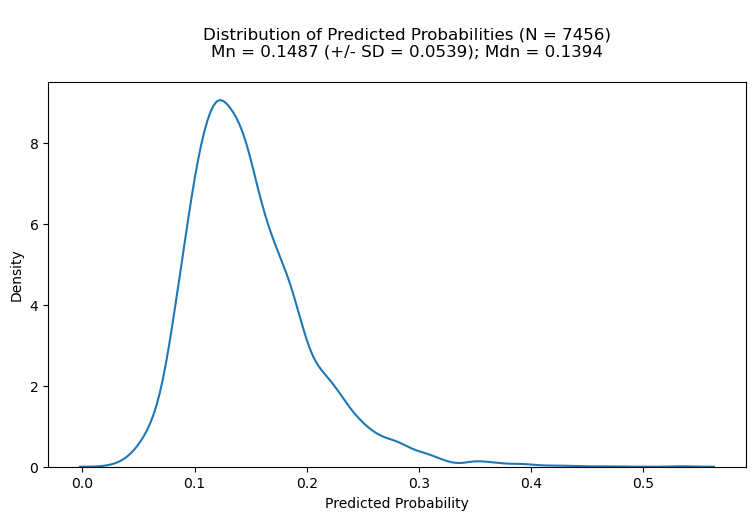

In [42]:
# distribution of predictions
plot_distribution_of_predictions(df=df)

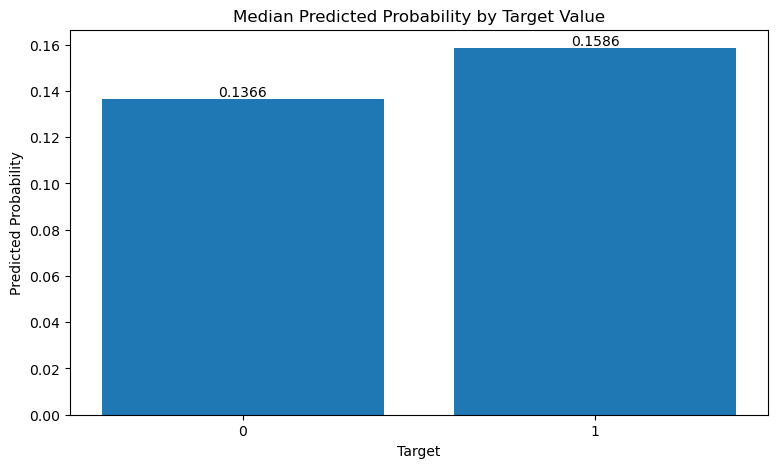

In [43]:
# median prediction by target
plot_median_prediction_by_target(df=df)

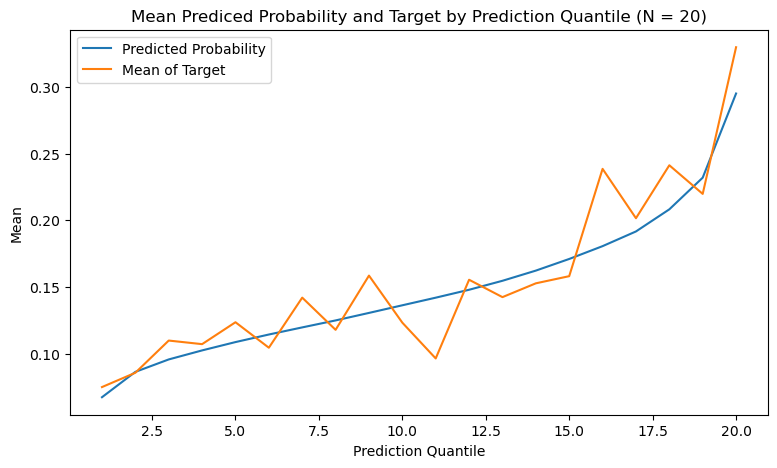

In [44]:
# mean target by prediction quantile
plot_mean_target_by_prediction_quantile(
    df=df,
    int_n_quantiles=int_n_quantiles,
)

100%|██████████| 3/3 [00:00<00:00, 36.28it/s]


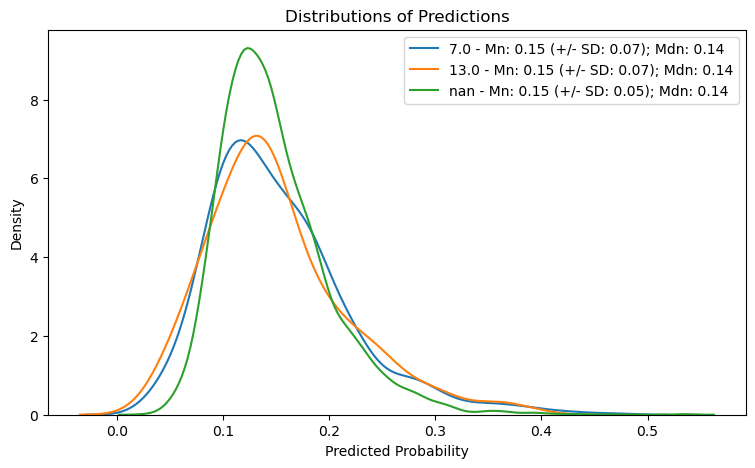

In [45]:
# distributions by bk type
plot_distributions_by_bk_type(df=df)

100%|██████████| 3/3 [00:00<00:00, 47.56it/s]


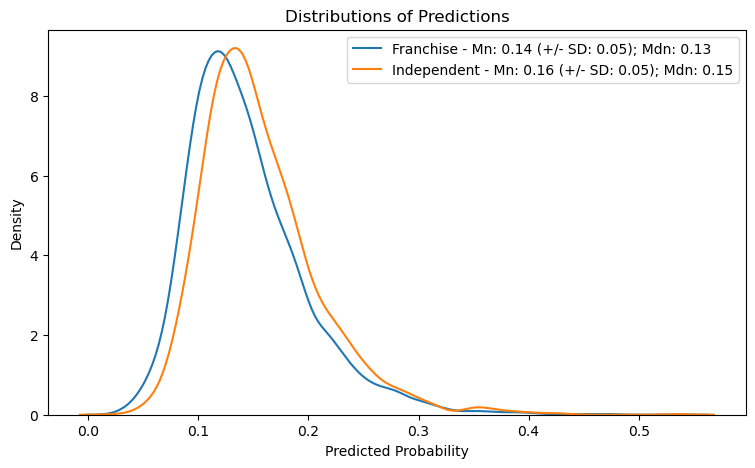

In [46]:
# distribution by dealership tracker type
plot_distributions_by_dealership_type(df=df)

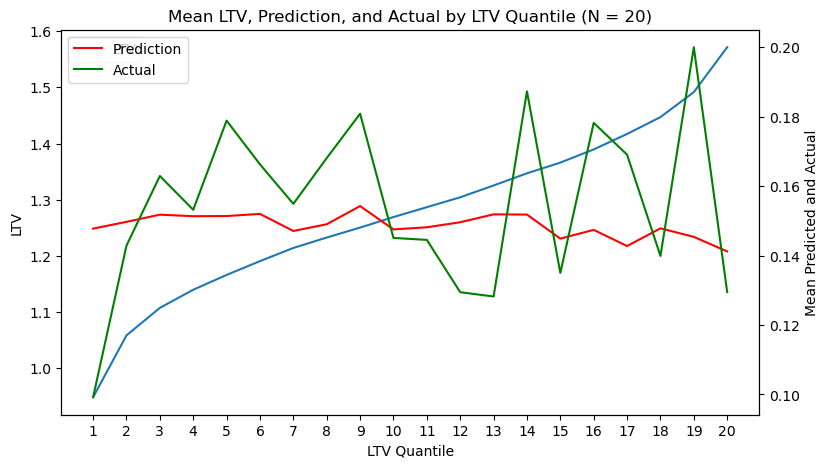

In [47]:
# mean ltv, yhat, and actual by ltv quantile
plot_mean_ltv_yhat_actual_by_ltv_quantile(
    df=df,
    int_n_quantiles=int_n_quantiles,
)

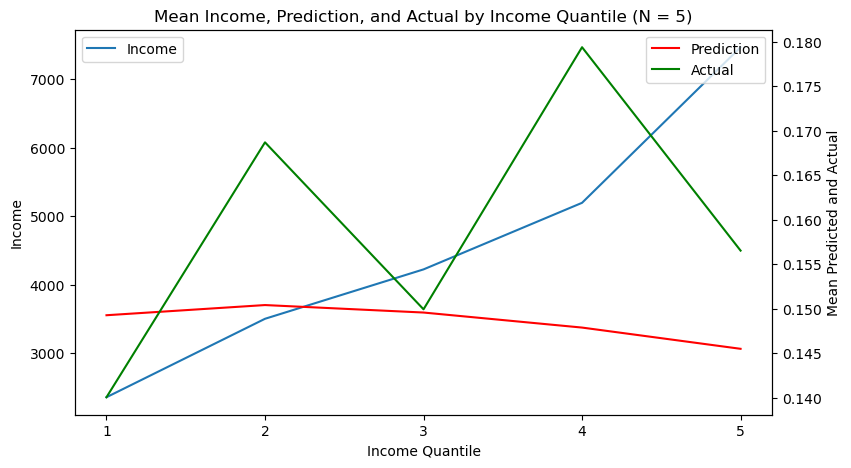

In [48]:
# income, predictions, and actuals by income quantile
plot_mean_income_yhat_actual_by_income_quantile(
    df=df,
    int_n_quantiles=5,
)